# CCLE 2019

The Cancer Cell Line Encyclopedia (CCLE) is a comprehensive resource of human cancer cell lines derived from various tissue types. These cell lines are cultured to proliferate indefinitely under in vitro conditions.

Developed primarily by the Broad Institute in collaboration with Novartis and other partners, CCLE aims to advance cancer biology research and drug discovery.

The collection enables large-scale drug screening and genomic studies, as the continuous proliferation of cell lines allows researchers to track genetic changes over time. However, a major limitation is the absence of the tumor microenvironment, which can affect translational relevance. Despite this, CCLE remains a cornerstone in cancer research and the development of precision medicine.



## Imports

In [37]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.manifold import TSNE
from scipy.stats import skew, kurtosis
from sklearn.decomposition import PCA
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
import umap
from combat.pycombat import pycombat
from sklearn.model_selection import train_test_split
import warnings


warnings.filterwarnings('ignore')

## Roadmap

In this notebook, we will analyze two different cancer cell lines using data from the **Cancer Cell Line Encyclopedia (CCLE)** study (Broad Institute, 2019) [2].

We obtained both expression and mutation data from **cBioPortal** by querying the CCLE dataset and downloading the following files:

- `data_mutations.txt`: Contains information about all gene mutations in the samples.  
- `data_mrna_seq_rpkm.txt`: Contains gene expression data in RPKM units, with genes as rows and samples as columns.

### Analysis Pipeline

For each dataset, we will follow the steps below:

1. **Methodology Overview**  
   - Outline the analytical approach and preprocessing strategy.

2. **Sample Analysis**  
   - Evaluate quality control (QC) metrics for samples.  
   - Filter out low-quality or incomplete samples.  
   - Visualize sample distributions and characteristics.

3. **Gene Analysis**  
   - Assess QC metrics for genes.  
   - Apply appropriate gene filtering.  
   - Explore overall expression trends.

4. **Dimensionality Reduction**  
   - Reduce data to 2D using techniques like PCA or t-SNE.  
   - Investigate linear separability and detect batch effects.

5. **Data Preparation for Classification**  
   - Merge mutation and expression datasets.  
   - Detect and correct for batch effects.  
   - Format the cleaned dataset for downstream classification tasks.


## Example Data

In [38]:
example_data_mutations = pd.read_csv('/Users/andreafabbricatore/Desktop/mac_bocconi/MAI/year 1/semester 2/ML Lab/AILAB/DATA/ccle_2019/data_mutations.txt',
                                      sep = '\t',
                                      comment = '#')
example_data_mutations.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,RNAseq_AC,SangerRecalibWES_AC,SangerWES_AC,TCGAhsCnt,WES_AC,WGS_AC,cDNA_Change,isCOSMIChotspot,isDeleterious,isTCGAhotspot
0,DVL1,1855,NaN,GRCh37,1,1277461,1277461,+,synonymous_variant,Silent,...,NaN,NaN,NaN,0,87:39,NaN,c.438G>A,False,False,False
1,AL590822.1,0,NaN,GRCh37,1,2144416,2144416,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,0,23:43,NaN,c.604C>T,False,False,False
2,PLCH2,9651,NaN,GRCh37,1,2435359,2435359,+,3_prime_UTR_variant,3'UTR,...,NaN,NaN,NaN,0,9:25,NaN,NaN,False,True,False
3,UBE4B,10277,NaN,GRCh37,1,10177641,10177641,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,0,13:95,NaN,c.934G>A,False,False,False
4,SRM,6723,NaN,GRCh37,1,11119363,11119363,+,synonymous_variant,Silent,...,NaN,NaN,NaN,0,113:57,NaN,c.207C>A,False,False,False


In [40]:
example_mRNA = pd.read_csv('/Users/andreafabbricatore/Desktop/mac_bocconi/MAI/year 1/semester 2/ML Lab/AILAB/DATA/ccle_2019/data_mrna_seq_rpkm.txt',
                    sep = '\t',
                    comment = '#')
example_mRNA.head()

,Hugo_Symbol,22RV1_PROSTATE,2313287_STOMACH,253JBV_URINARY_TRACT,253J_URINARY_TRACT,42MGBA_CENTRAL_NERVOUS_SYSTEM,5637_URINARY_TRACT,59M_OVARY,639V_URINARY_TRACT,647V_URINARY_TRACT,...,UMUC16_URINARY_TRACT,UMUC4_URINARY_TRACT,UMUC5_URINARY_TRACT,UMUC6_URINARY_TRACT,UMUC7_URINARY_TRACT,UMUC9_URINARY_TRACT,UPCISCC152_UPPER_AERODIGESTIVE_TRACT,UW228_CENTRAL_NERVOUS_SYSTEM,Y79_AUTONOMIC_GANGLIA,YAMATO_SOFT_TISSUE
0,DDX11L1,0.00000,0.03755,0.00000,0.06507,0.00000,0.01378,0.01463,0.03085,0.00000,...,0.00000,0.02977,0.02999,0.03532,0.03831,0.03236,0.00000,0.03799,0.02907,0.00000
1,WASH7P,12.63011,10.14155,6.20657,6.55835,7.61752,6.19356,4.62277,6.00767,4.70699,...,6.42321,8.17443,7.75149,9.97036,8.17080,8.70551,15.23348,6.47732,8.45568,11.81688
2,MIR1302-11,0.04289,0.01037,0.16955,0.23364,0.08765,0.00000,0.00808,0.09373,0.02568,...,0.12367,0.19183,0.10492,0.18537,0.07408,0.07747,0.07448,0.01049,0.39607,0.17586
3,FAM138A,0.00000,0.00869,0.22423,0.16558,0.00000,0.00637,0.00000,0.01427,0.00000,...,0.01554,0.00459,0.01850,0.04903,0.01330,0.00000,0.02674,0.00879,0.26449,0.02266
4,OR4G4P,0.00000,0.00000,0.02886,0.03875,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00667,0.01182,0.01786,0.01052,0.01141,0.00642,0.00000,0.00000,0.00000,0.01459


In [42]:
# Free memory
del example_data_mutations, example_mRNA

## Utils

In [43]:
def plot_violin_metrics(data, axis):
    """
    Plot violin plots of various QC metrics across genes or samples.

    Parameters:
        data (pd.DataFrame): Gene expression matrix (genes x samples)
        axis (int): 0 for sample-wise metrics, 1 for gene-wise metrics
    """
    axis_name = "Genes" if axis == 1 else "Samples"
    stats = {
        'Total Counts': data.sum(axis=axis),
        'Mean': data.mean(axis=axis),
        'Median': data.median(axis=axis),
        'Standard Deviation': data.std(axis=axis),
        'Coefficient of Variation': data.std(axis=axis) / data.mean(axis=axis),
        'Total Features': data.astype(bool).sum(axis=axis)
    }

    fig, ax = plt.subplots(1, len(stats), figsize=(25, 12))
    colors = ['firebrick', 'steelblue', 'orange', 'darkgreen', 'indigo', 'silver']

    for i, (metric, values) in enumerate(stats.items()):
        sns.violinplot(y=values.reset_index(drop=True), ax=ax[i], color=colors[i])
        ax[i].set_title(f'{metric} Across {axis_name}')
        ax[i].set_xlabel('')
        ax[i].grid(True)

        print(f'Max {metric.lower()}: {values.max():.2f} | Min {metric.lower()}: {values.min():.2f} | Range: {(values.max() - values.min()):.2f}')

    plt.tight_layout()
    plt.show()


def plot_skewness_kurtosis(data, axis):
    """
    Plot bar plots of skewness and kurtosis for gene/sample expression.

    Parameters:
        data (pd.DataFrame): Gene expression matrix (genes x samples)
        axis (int): 0 for sample-wise, 1 for gene-wise
    """
    skew_vals = data.apply(skew, axis=axis)
    kurt_vals = data.apply(kurtosis, axis=axis)
    target = "Sample" if axis == 0 else "Gene"

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.bar(range(len(skew_vals)), skew_vals.values, color='mediumpurple')
    plt.title(f"Skewness of Expression per {target}")
    plt.xlabel(f"{target} Index")
    plt.ylabel("Skewness")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.bar(range(len(kurt_vals)), kurt_vals.values, color='darkorange')
    plt.title(f"Excess Kurtosis per {target}")
    plt.xlabel(f"{target} Index")
    plt.ylabel("Kurtosis")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def heatmap_plot(title, data, samples):
    """
    Plot Pearson correlation heatmap between samples.

    Parameters:
        title (str): Title of the plot
        data (pd.DataFrame): Gene expression matrix (genes x samples)
        samples (list): Subset of sample column names to include in the heatmap
    """
    plt.figure(figsize=(10, 8))
    plt.title(title)
    sns.heatmap(data.loc[:, samples].corr(), cmap='viridis', annot=False)
    plt.show()
    print(f"Number of samples plotted: {len(samples)} x {len(samples)}")


def plot_PCA_tsne_umap(data_ordered, mutated_samples, non_mutated_samples, title, categories):
    """
    Generate a combined plot of PCA, t-SNE, and UMAP for mutated vs non-mutated samples.

    Parameters:
        data_ordered (pd.DataFrame): Gene expression matrix (genes x samples)
        mutated_samples (list): Sample names with mutation
        non_mutated_samples (list): Sample names without mutation
        title (str): Plot title
        categories (tuple): (label_for_mutated, label_for_non_mutated)
    """
    all_samples = mutated_samples + non_mutated_samples
    labels = [categories[0]] * len(mutated_samples) + [categories[1]] * len(non_mutated_samples)
    label_map = {label: idx for idx, label in enumerate(categories)}
    colors = [label_map[label] for label in labels]
    
    X = data_ordered[all_samples].T.values

    reducers = {
        "PCA": PCA(n_components=2, random_state=42).fit_transform(X),
        "t-SNE": TSNE(n_components=2, random_state=42, learning_rate='auto', init='random').fit_transform(X),
        "UMAP": umap.UMAP(n_components=2, random_state=42).fit_transform(X),
    }

    plt.figure(figsize=(18, 5))
    for i, (name, result) in enumerate(reducers.items(), 1):
        plt.subplot(1, 3, i)
        plt.scatter(result[:, 0], result[:, 1], c=colors, cmap='viridis', alpha=0.8)
        plt.title(f"{name}: {categories[0]} vs {categories[1]}")
        plt.xlabel(f"{name}1")
        plt.ylabel(f"{name}2")
        plt.grid(True)

    handles = [
        plt.Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(label_map[cat]), label=cat)
        for cat in categories
    ]
    plt.legend(handles=handles, title='Category', loc='upper right')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def standard(df):
    """
    Standardize expression values (zero mean, unit variance) across each feature.

    Parameters:
        df (pd.DataFrame): Gene expression matrix (genes x samples)

    Returns:
        pd.DataFrame: Standardized expression matrix
    """
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df.T).T  # Scale features (genes), not samples
    return pd.DataFrame(scaled, index=df.index, columns=df.columns)

## Data Collection

In [51]:
import pandas as pd

# --------- Load mRNA Expression Data ---------
mRNA_path = '/Users/andreafabbricatore/Desktop/mac_bocconi/MAI/year 1/semester 2/ML Lab/AILAB/DATA/ccle_2019/data_mrna_seq_rpkm.txt'

mRNA_2019 = pd.read_csv(mRNA_path, sep='\t', comment='#')
mRNA_2019.set_index('Hugo_Symbol', inplace=True)

# Merge duplicate genes by averaging expression values
mRNA_2019 = mRNA_2019.groupby(mRNA_2019.index).mean()

# --------- Load Mutation Data (TP53 only) ---------
mut_path = '/Users/andreafabbricatore/Desktop/mac_bocconi/MAI/year 1/semester 2/ML Lab/AILAB/DATA/ccle_2019/data_mutations.txt'

mut_all_2019 = pd.read_csv(mut_path, sep='\t', comment='#')

# Filter only TP53 mutations
mut_all_2019 = mut_all_2019[mut_all_2019['Hugo_Symbol'] == 'TP53']

# Keep only sample ID and mutation type
mut_all_2019 = mut_all_2019[['Tumor_Sample_Barcode', 'Variant_Type']]
mut_all_2019.set_index('Tumor_Sample_Barcode', inplace=True)

# --------- Filter Inconsistent Mutation Annotations ---------
variant_check = mut_all_2019.groupby(mut_all_2019.index)["Variant_Type"].nunique()
consistent_samples = variant_check[variant_check == 1].index
inconsistent_samples = variant_check[variant_check != 1].index

# Keep only consistent mutation samples
mut_all_2019 = mut_all_2019.loc[consistent_samples]

# Drop inconsistent samples from mRNA data
mRNA_2019 = mRNA_2019.drop(columns=[col for col in inconsistent_samples if col in mRNA_2019.columns])

# Remove duplicates (keep one mutation type per sample)
mut_all_2019 = mut_all_2019[~mut_all_2019.index.duplicated(keep='first')]

# --------- Create Wild-Type (WT) Annotations ---------
all_samples = set(mRNA_2019.columns)
mutated_samples = set(mut_all_2019.index)
wt_samples = all_samples - mutated_samples

# Assign 'WT' to those samples
wt_df = pd.DataFrame(index=list(wt_samples))
wt_df['Variant_Type'] = 'WT'

# Combine WT and Mutated samples
mut_all_2019 = pd.concat([mut_all_2019, wt_df])

# Reorder to match mRNA sample columns
mut_all_2019 = mut_all_2019.loc[mRNA_2019.columns]

# --------- Final Output (Optional) ---------
# You now have:
# - `mRNA_2019`: gene expression matrix (genes x samples)
# - `mut_all_2019`: TP53 mutation status per sample (with 'WT')

# Example: inspect how many samples are WT vs Mutated
print(mut_all_2019['Variant_Type'].value_counts())


Variant_Type
SNP    625
WT     402
DEL     70
INS     18
DNP      2
Name: count, dtype: int64


## Sample filtering

In [52]:
# Shape of mRNA
print(f'Number of genes: {len(mRNA_2019.index)}\nNumber of samples: {len(mRNA_2019.columns)}')
print(f'Zero entries: {(mRNA_2019 <= 0).sum().sum()}') # entries all positive no zeros
print("The sparsity of the data is due to the fact that the technique used to measure the expression is bulk RNAseq")

Number of genes: 54353
Number of samples: 1117
Zero entries: 28856037


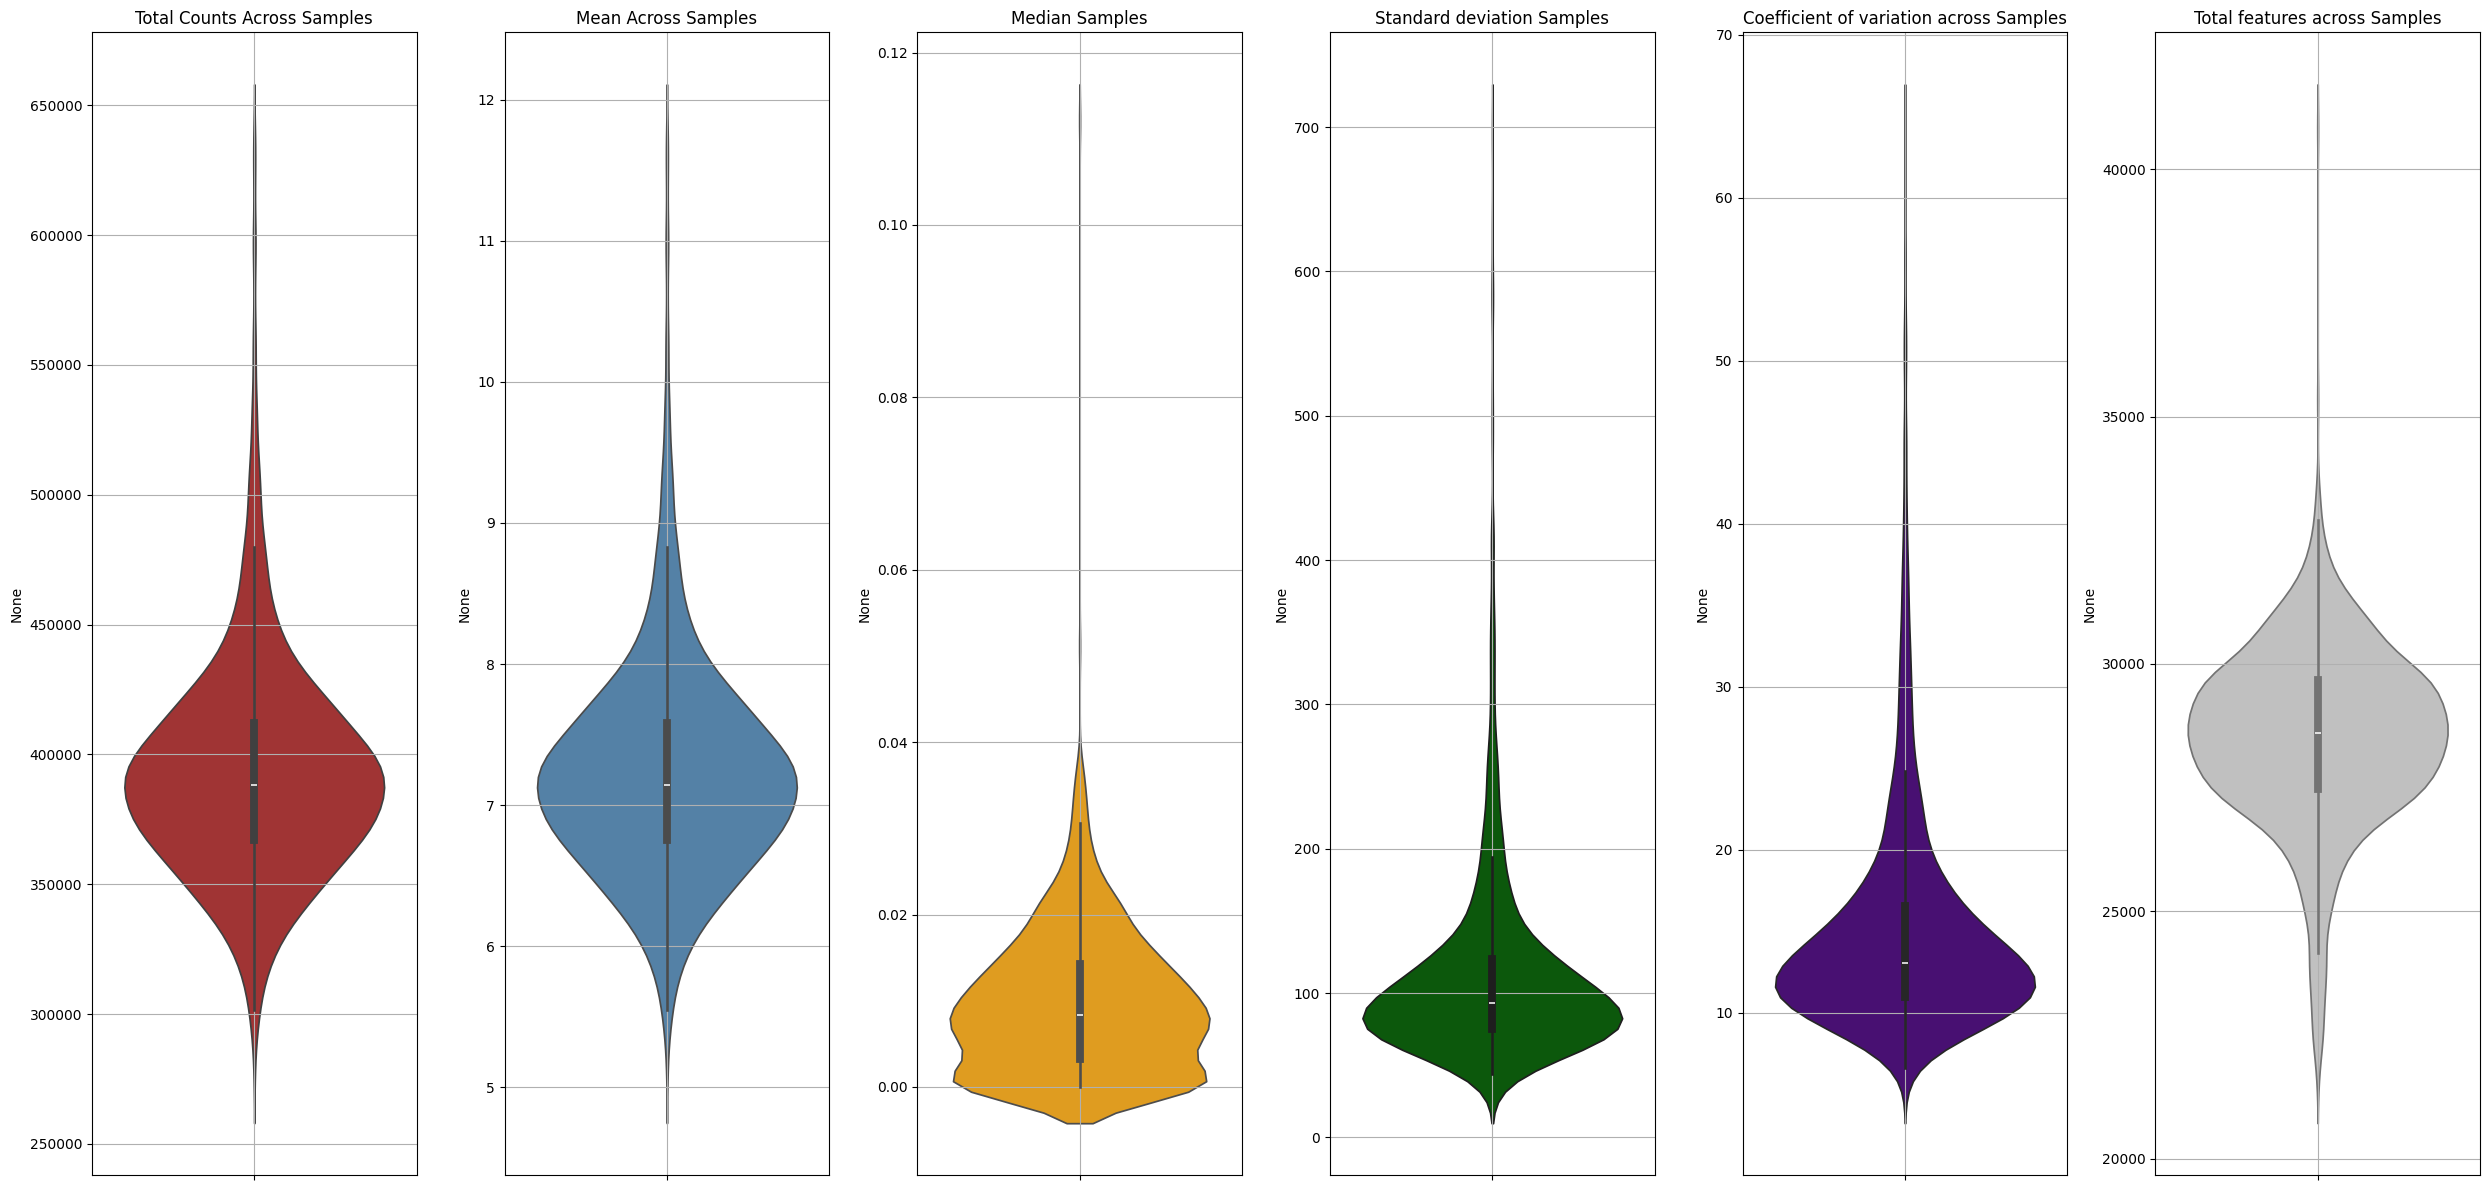

Max_total_count (637183.6959461462) - Min_total_count (278917.46269149065) = 358266.2332546555
Max_mean_count (11.723063969719172) - Min_mean_count (5.131592785890211) = 6.591471183828961
Max_median_count (0.11212) - Min_median_count (0.0) = 0.11212
Max_std (695.8833828041955) - Min_std (43.6293928644234) = 652.2539899397722
Max CV (63.58381480149525) - Min CV (6.623955659040309) = 56.959859142454945
Max feature count  (40815) - Min feature count (21619) = 19196


In [53]:
# Plot QC metrics
plot_violin_metrics(mRNA_2019,0)

The quality metrics appear mostly well-behaved, with consistent total and mean expression values across genes, reflecting the effects of RPKM normalization — as indicated by the high but relatively uniform count values.

However, the Coefficient of Variation (CV) shows substantial spread, with some genes having a CV above 60, suggesting high variability relative to their mean expression. This level of dispersion can indicate the presence of noisy or unstable genes. It is therefore reasonable to apply filters to remove genes with extremely high CV values, which may help improve downstream analyses by focusing on more stable expression patterns.

In [54]:
# Filter out genes with a coefficient of variation more than 55
cv_genes = mRNA_2019.std(axis = 0)/mRNA_2019.mean(axis = 0) 
samples_to_keep = cv_genes[cv_genes < 55].index

mRNA_2019 = mRNA_2019[samples_to_keep]
mut_all_2019 = mut_all_2019.loc[samples_to_keep]

corr_matrix = mRNA_2019.corr()
print('Minimum correlation between samples:',corr_matrix.describe().loc['min'].min())
print('Minimum mean correlation between samples:',corr_matrix.describe().loc['mean'].min())

In [56]:
mutated_samples = mut_all_2019[mut_all_2019['Variant_Type'] != 'WT'].index
non_mutated_samples = mut_all_2019[mut_all_2019['Variant_Type'] == 'WT'].index


random_samples_mut_100 = np.random.choice(mutated_samples,size = 100)
random_samples_non_mut_100 = np.random.choice(non_mutated_samples,size = 100)
random_samples_mut_50_non_mut50 = list(random_samples_mut_100[:50]) + list(random_samples_non_mut_100[:50])

Let us see how the mutations are distributed

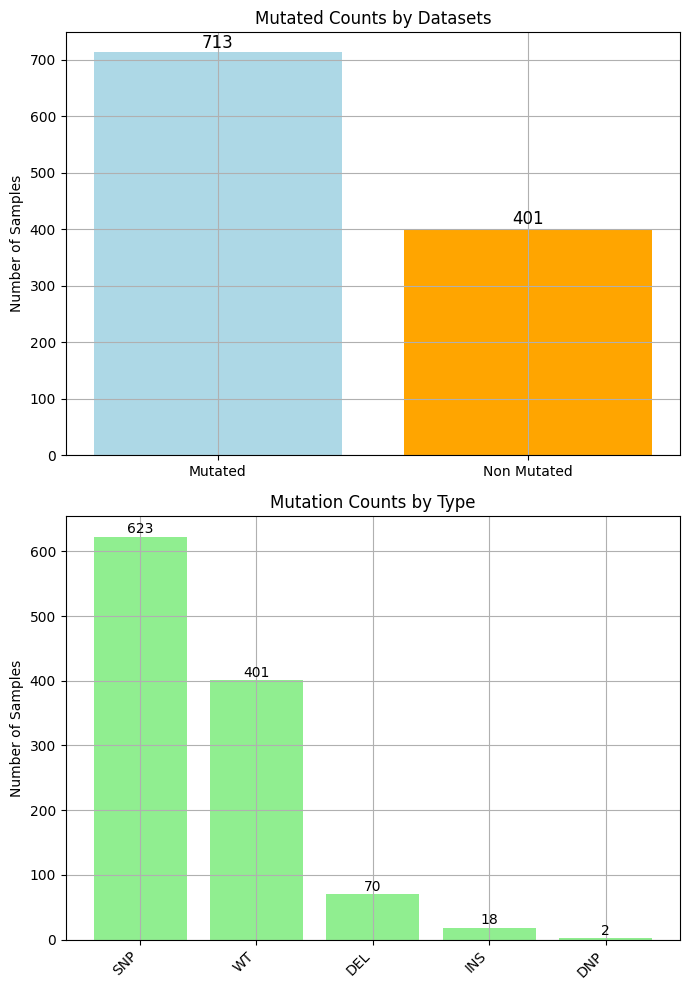

In [58]:
# --- Plot Sample Counts and Mutation Types ---

# Data: Count of mutated and non-mutated samples
sample_counts = [len(mutated_samples), len(non_mutated_samples)]

# Data: Count of mutation types
mutation_counts = mut_all_2019['Variant_Type'].value_counts()

# Create subplots (2 rows, 1 column)
fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# --- Plot 1: Mutated vs Non-Mutated Sample Counts ---
axs[0].bar(['Mutated', 'Non-Mutated'], sample_counts, color=['skyblue', 'orange'])
axs[0].set_title("Sample Counts by Mutation Status", fontsize=14)
axs[0].set_ylabel("Number of Samples")
axs[0].grid(True, axis='y')

# Add count labels above bars
for i, count in enumerate(sample_counts):
    axs[0].text(i, count + 1, str(count), ha='center', va='bottom', fontsize=12)

# --- Plot 2: Mutation Counts by Type ---
axs[1].bar(mutation_counts.index, mutation_counts.values, color='lightgreen')
axs[1].set_title("Mutation Counts by Type", fontsize=14)
axs[1].set_ylabel("Number of Mutations")
axs[1].set_xticks(range(len(mutation_counts)))
axs[1].set_xticklabels(mutation_counts.index, rotation=45, ha='right')
axs[1].grid(True, axis='y')

# Layout adjustment
plt.tight_layout()
plt.show()

Can we find correlations in the samples?

Number of samples plotted: (100, 100)


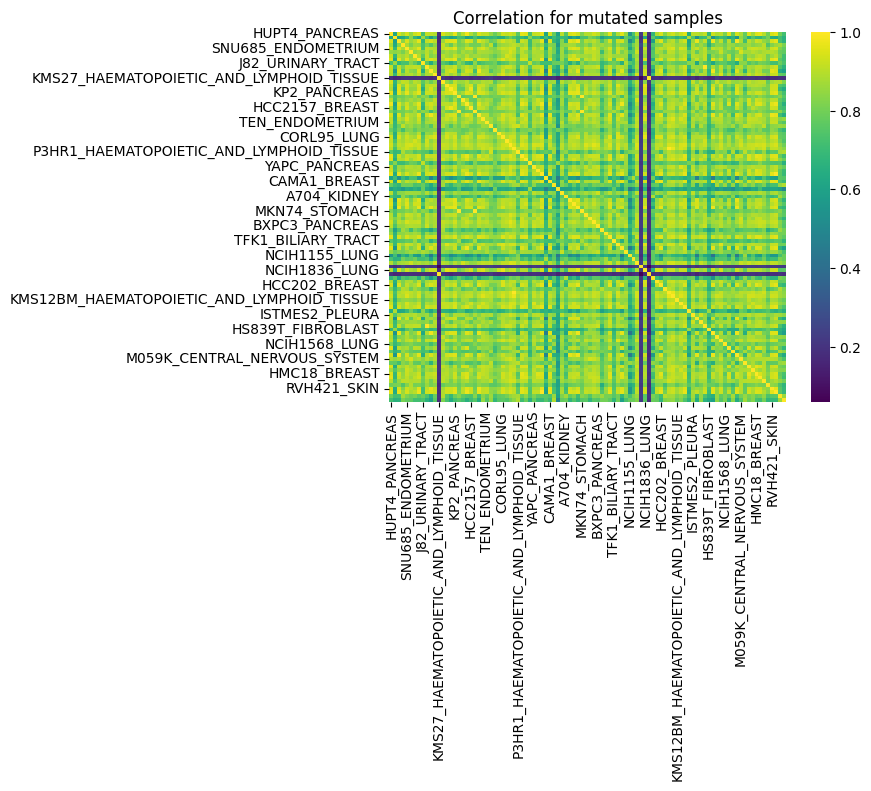

In [59]:
heatmap_plot('Correlation for mutated samples',mRNA_2019,random_samples_mut_100)

Number of samples plotted: (100, 100)


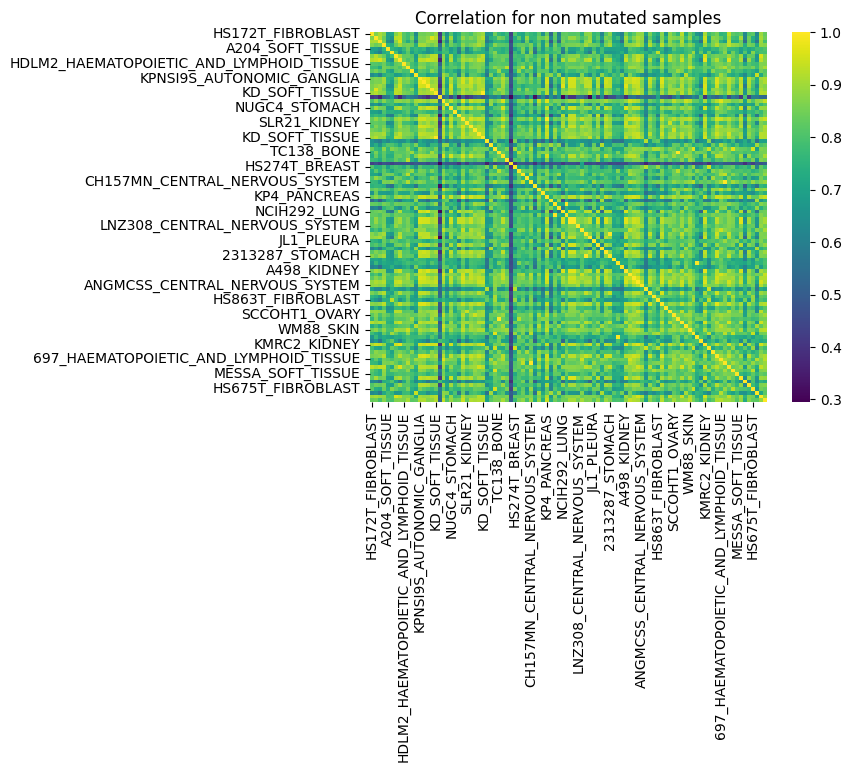

In [60]:
heatmap_plot('Correlation for non mutated samples',mRNA_2019,random_samples_non_mut_100)

Number of samples plotted: (100, 100)


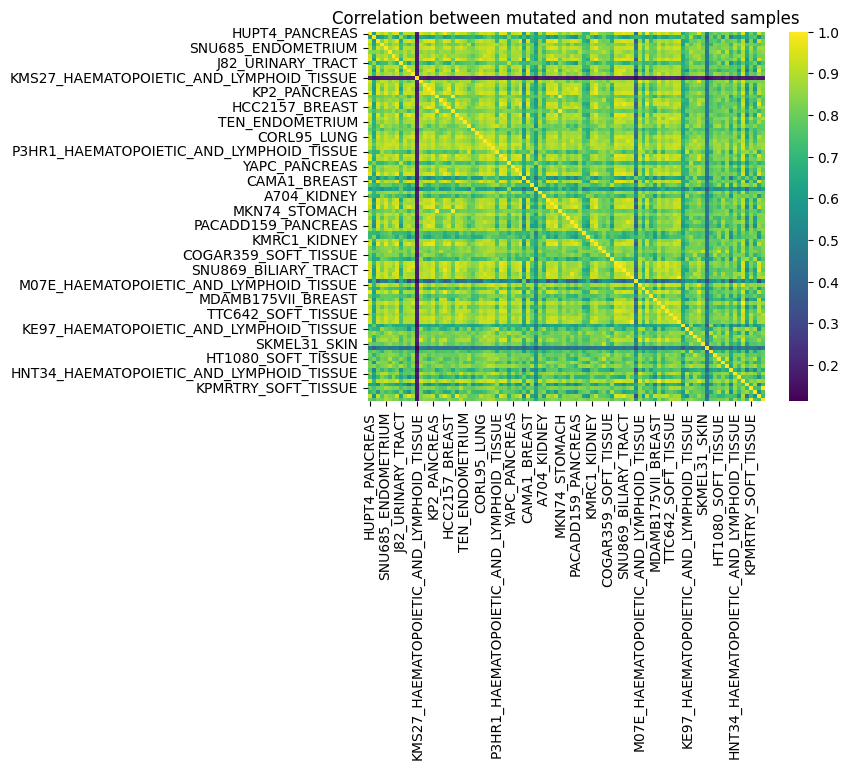

In [61]:
heatmap_plot('Correlation between mutated and non mutated samples',mRNA_2019,random_samples_mut_50_non_mut50)

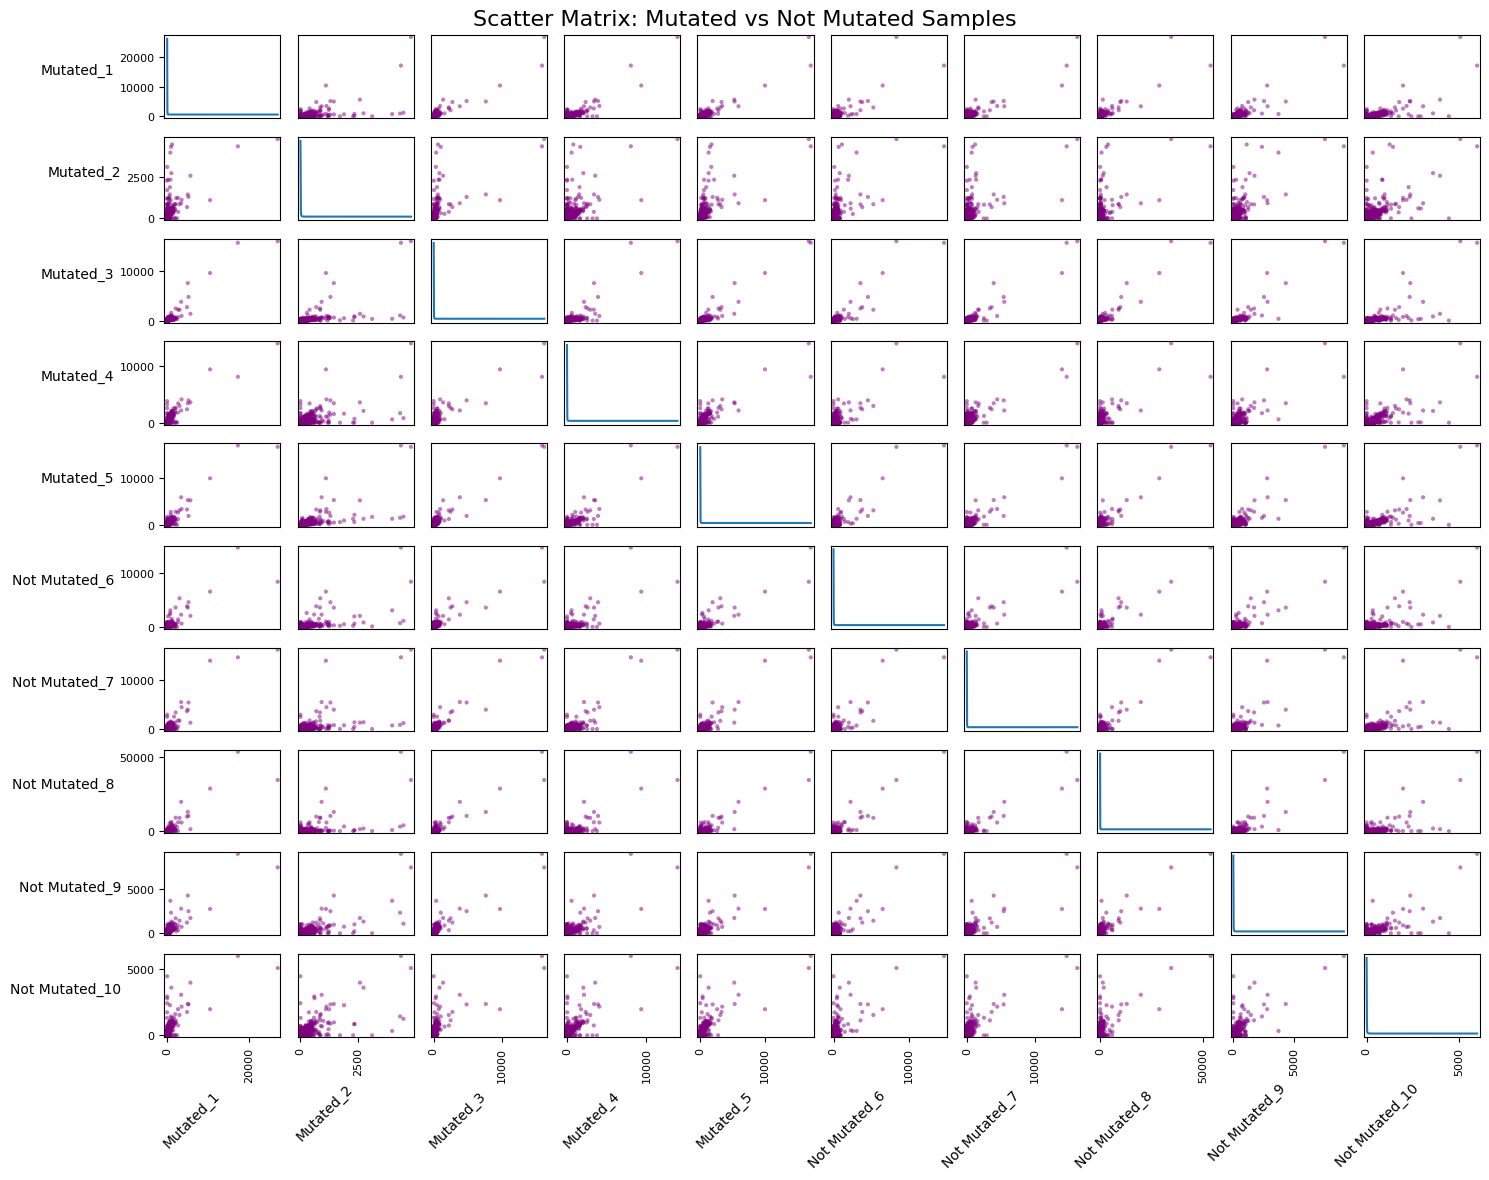

In [62]:
# --- Select and Prepare Sample Subset for Scatter Matrix ---

# Combine 5 mutated and 5 non-mutated sample IDs
selected_ids = random_samples_mut_100[:5].tolist() + random_samples_non_mut_100[:5].tolist()

# Subset expression data for selected samples
subset_expr = mRNA_2019.loc[:, selected_ids]

# Rename columns for clarity (e.g., Mutated_1, Not Mutated_1, etc.)
labels = ['Mutated'] * 5 + ['Not Mutated'] * 5
subset_expr.columns = [f"{label}_{i+1}" for i, label in enumerate(labels)]

# Generate scatter matrix
axes = scatter_matrix(subset_expr, diagonal='kde', figsize=(15, 12), color='purple')

# Rotate x and y axis labels for readability
for ax in axes.ravel():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), rotation=45, ha='right')
        ax.set_ylabel(ax.get_ylabel(), rotation=0, ha='right')

# Final touches
plt.suptitle("Scatter Matrix: Mutated vs Not Mutated Samples", fontsize=16)
plt.tight_layout()
plt.show()


In [63]:
# --- Correlation Summary for Mutated and Non-Mutated Samples ---

def print_correlation_stats(group_name, sample_ids, data):
    corr_matrix = data.loc[:, sample_ids].corr()
    stats = corr_matrix.describe()
    
    print(f"---- {group_name} Samples ----")
    print(f"1) Minimum pairwise correlation: {stats.loc['min'].min():.4f}")
    print(f"2) Minimum average correlation per sample: {stats.loc['mean'].min():.4f}\n")

# Mutated Samples
print_correlation_stats("Mutated", mutated_samples, mRNA_2019)

# Non-Mutated Samples
print_correlation_stats("Non-Mutated", non_mutated_samples, mRNA_2019)

----Mutated Samples-----
1) Minimum correlation between samples: 0.03066116944826166
2) Minimum mean correlation between samples: 0.11419364877755643
----Non Mutated Samples-------
1) Minimum correlation between samples: 0.06202864764726494
2) Minimum mean correlation between samples: 0.20193250592842465


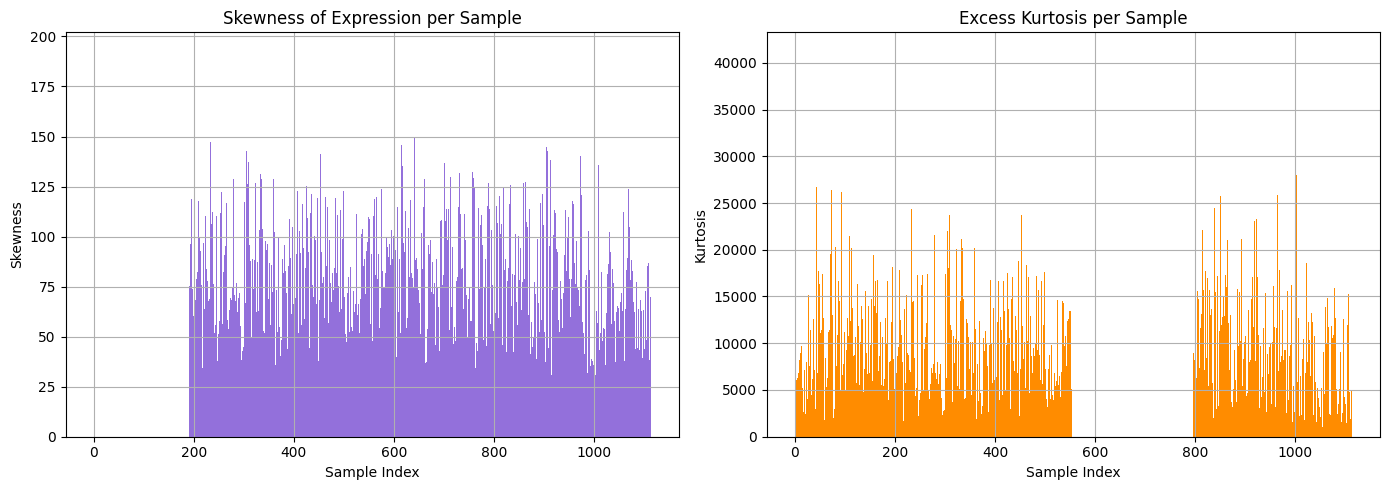

In [64]:
plot_skewness_kurtosis(mRNA_2019,0)

### Skewness and Kurtosis Analysis

Both **skewness** and **kurtosis** are positive across all samples:

- **Positive skewness** indicates that the distribution of gene expression values is **right-skewed** within each sample. This means that while most genes have low to moderate expression, a small number of genes exhibit **very high expression levels**. This pattern is expected in RNA-seq data normalized using **RPKM**, where a subset of genes dominates the overall expression landscape.

- **Positive excess kurtosis** suggests that the expression distributions are **leptokurtic** — characterized by **sharper peaks** and **heavier tails** than a normal distribution. In practical terms, this implies that expression values are more tightly clustered around the mean, but with a higher probability of **extreme expression values** occurring.

These characteristics reflect the **non-Gaussian nature** of gene expression data and underscore the importance of appropriate normalization and transformation techniques in downstream analyses.


## Gene Filtering

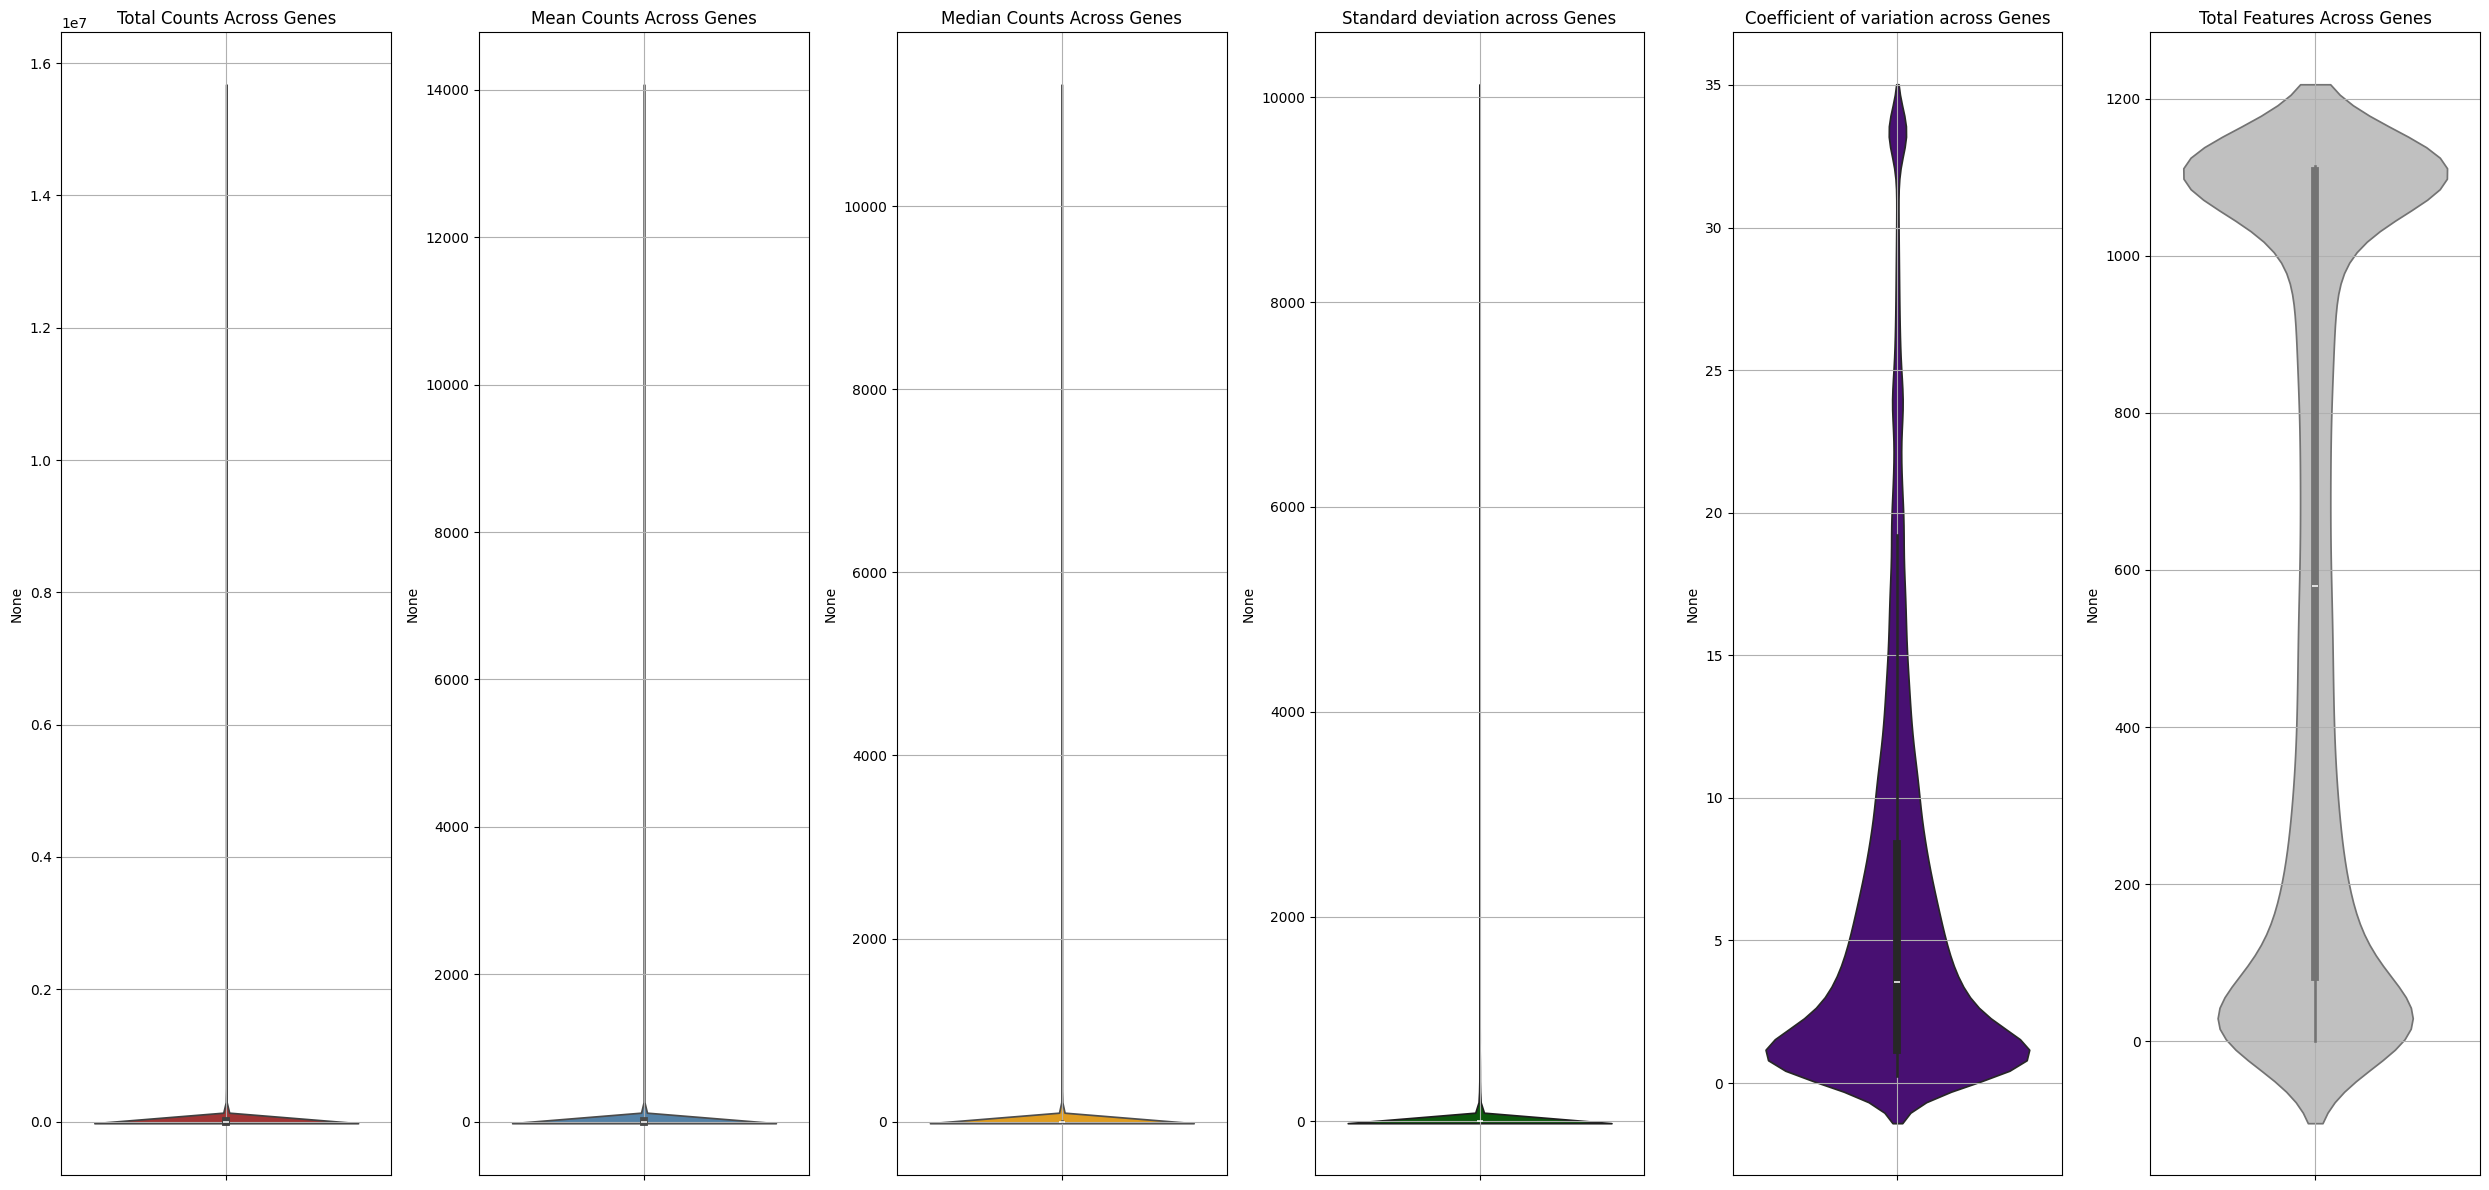

Max_total_count (15656132.74128) - Min_total_count (0.0) = 15656132.74128
Max_mean_count (14053.979121436267) - Min_mean_count (0.0) = 14053.979121436267
Max_median_count (11316.20996) - Min_median_count (0.0) = 11316.20996
Max std  (10110.172948055253) - Min std (0.0) = 10110.172948055253
Max cv  (33.37663853655729) - Min cv (0.2393238608455569) = 33.13731467571173
Max feature count  (1114) - Min feature count (0) = 1114


In [65]:
plot_violin_metrics(mRNA_2019,1)

### Gene-Level Quality Control Summary

The violin plots and QC metrics reveal a highly skewed distribution of expression across genes:

- Several genes have **extremely high total and mean expression**, while many others have **zero or near-zero counts**. This is evident from the wide range in total counts (0 to over 15 million) and median expression (0 to over 11,000).
- The **standard deviation** and **coefficient of variation (CV)** also show large spreads, indicating **substantial variability** across the dataset.
- The **feature count** metric highlights that some genes are expressed in nearly all samples, while others have **no detectable expression at all**.

This pattern suggests the presence of a large number of **sparse or uninformative genes**, which can inflate noise and distort downstream analyses such as dimensionality reduction or classification.

To improve data quality and reduce unnecessary variation, we will apply **gene filtering** — specifically removing genes with consistently low or zero expression across samples.


In [66]:
threshold = mRNA_2019.shape[1]*(0.1)
genes_to_keep = mRNA_2019.astype(bool).sum(axis=1)[mRNA_2019.astype(bool).sum(axis=1) > threshold].index
mRNA_2019 = mRNA_2019.loc[genes_to_keep]

What about distribution after filtering?

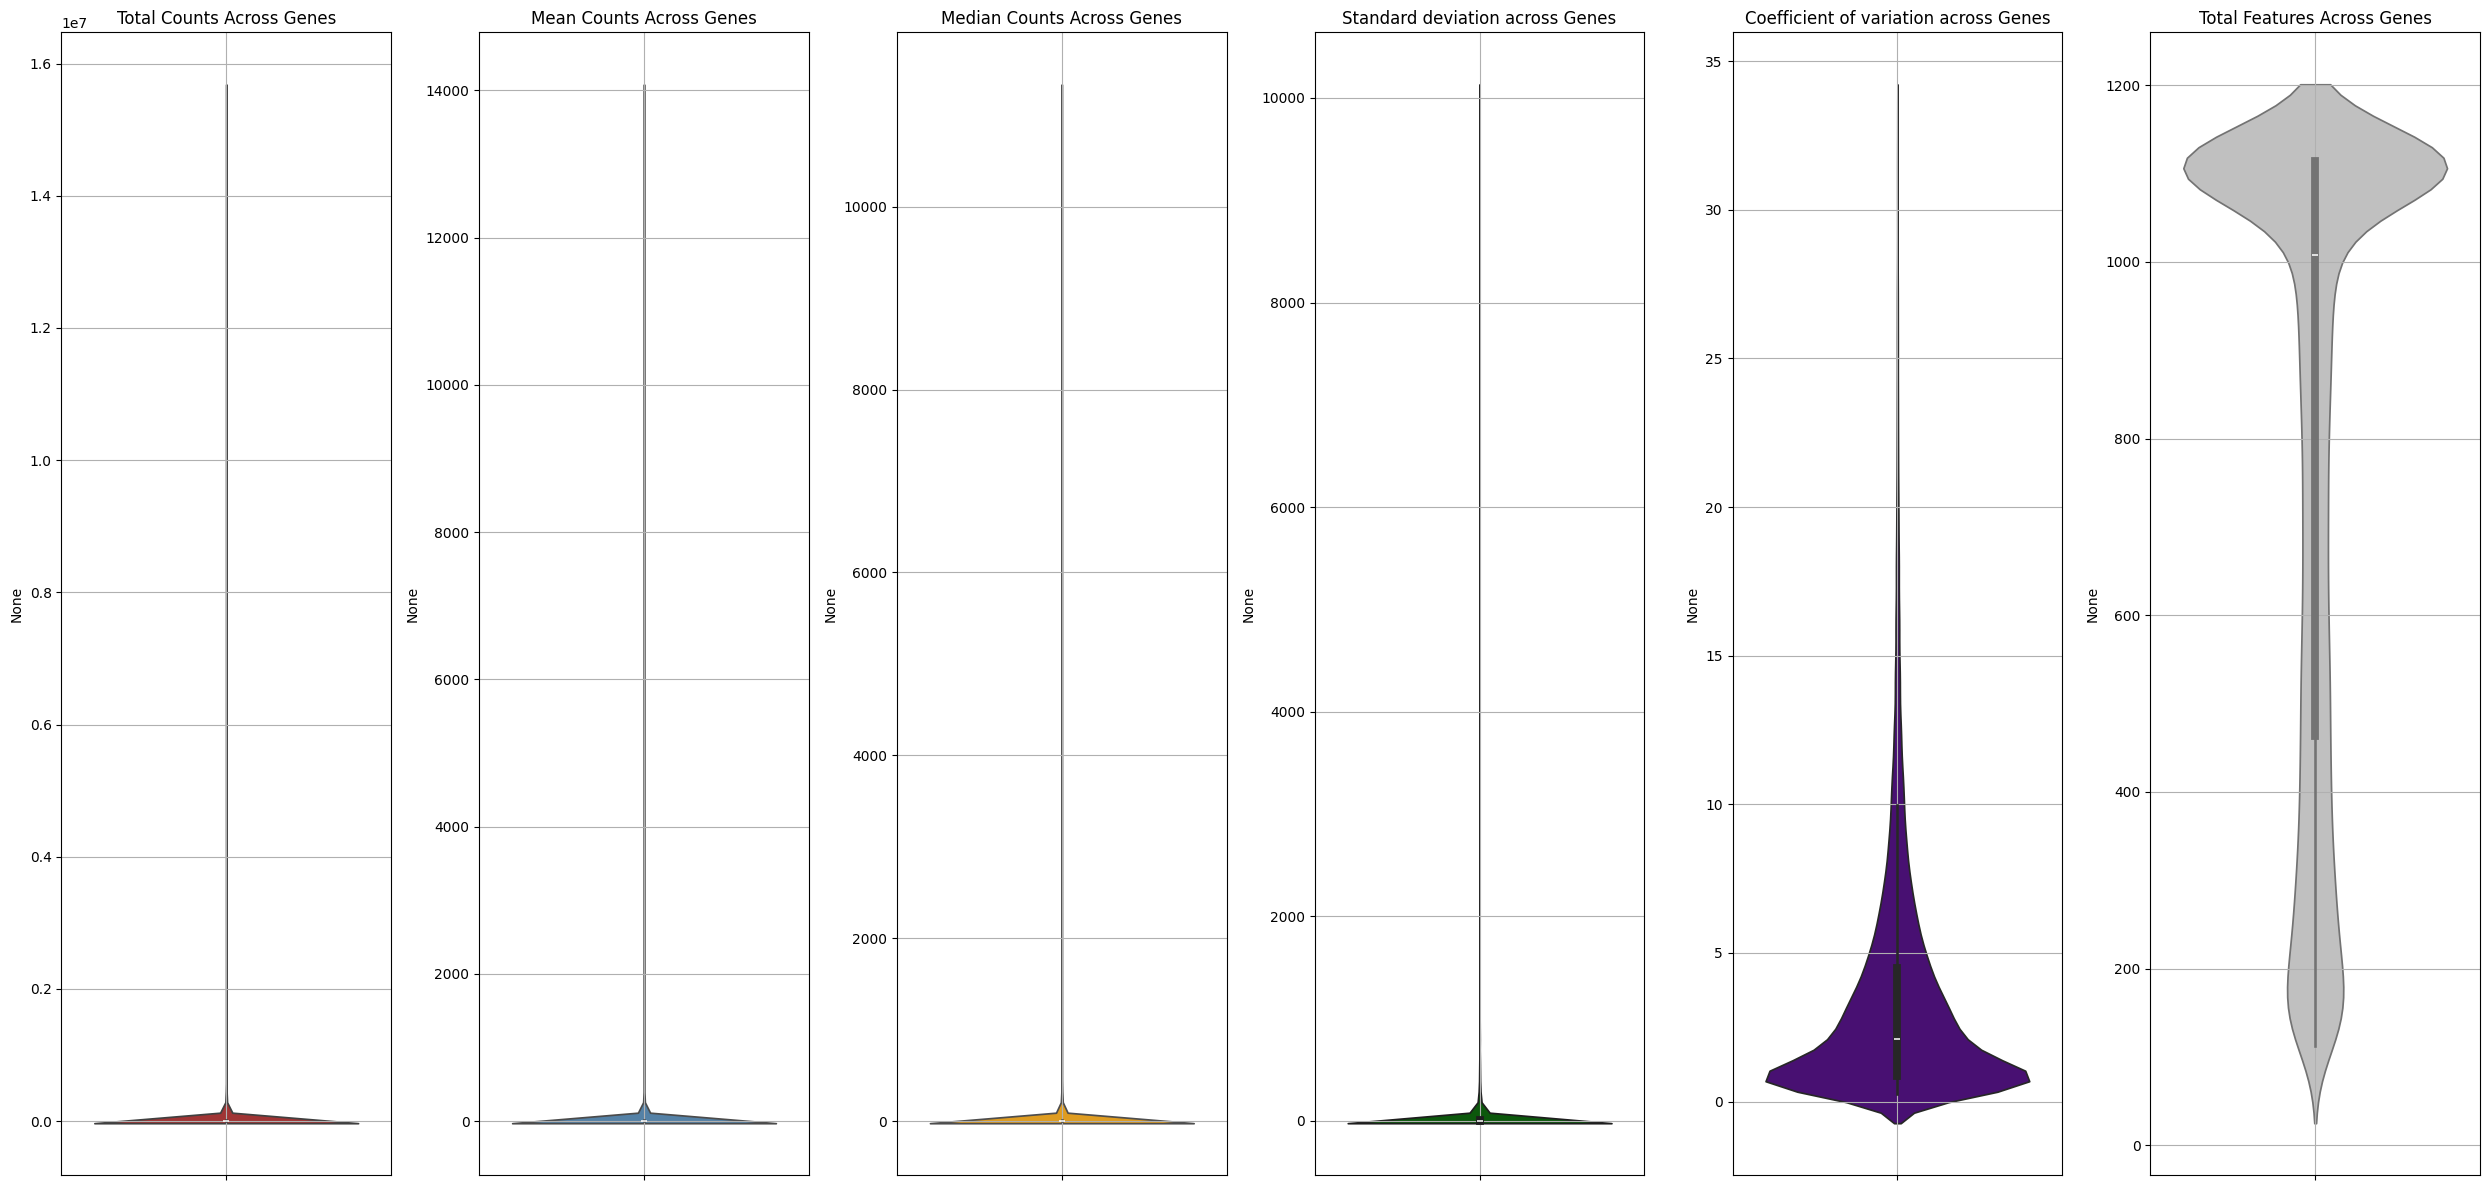

Max_total_count (15656132.74128) - Min_total_count (0.52789) = 15656132.21339
Max_mean_count (14053.979121436267) - Min_mean_count (0.00047386894075403946) = 14053.978647567326
Max_median_count (11316.20996) - Min_median_count (0.0) = 11316.20996
Max std  (10110.172948055253) - Min std (0.0014981310383758053) = 10110.171449924215
Max cv  (33.25557223007247) - Min cv (0.2393238608455569) = 33.01624836922691
Max feature count  (1114) - Min feature count (112) = 1002


In [67]:
plot_violin_metrics(mRNA_2019,1)

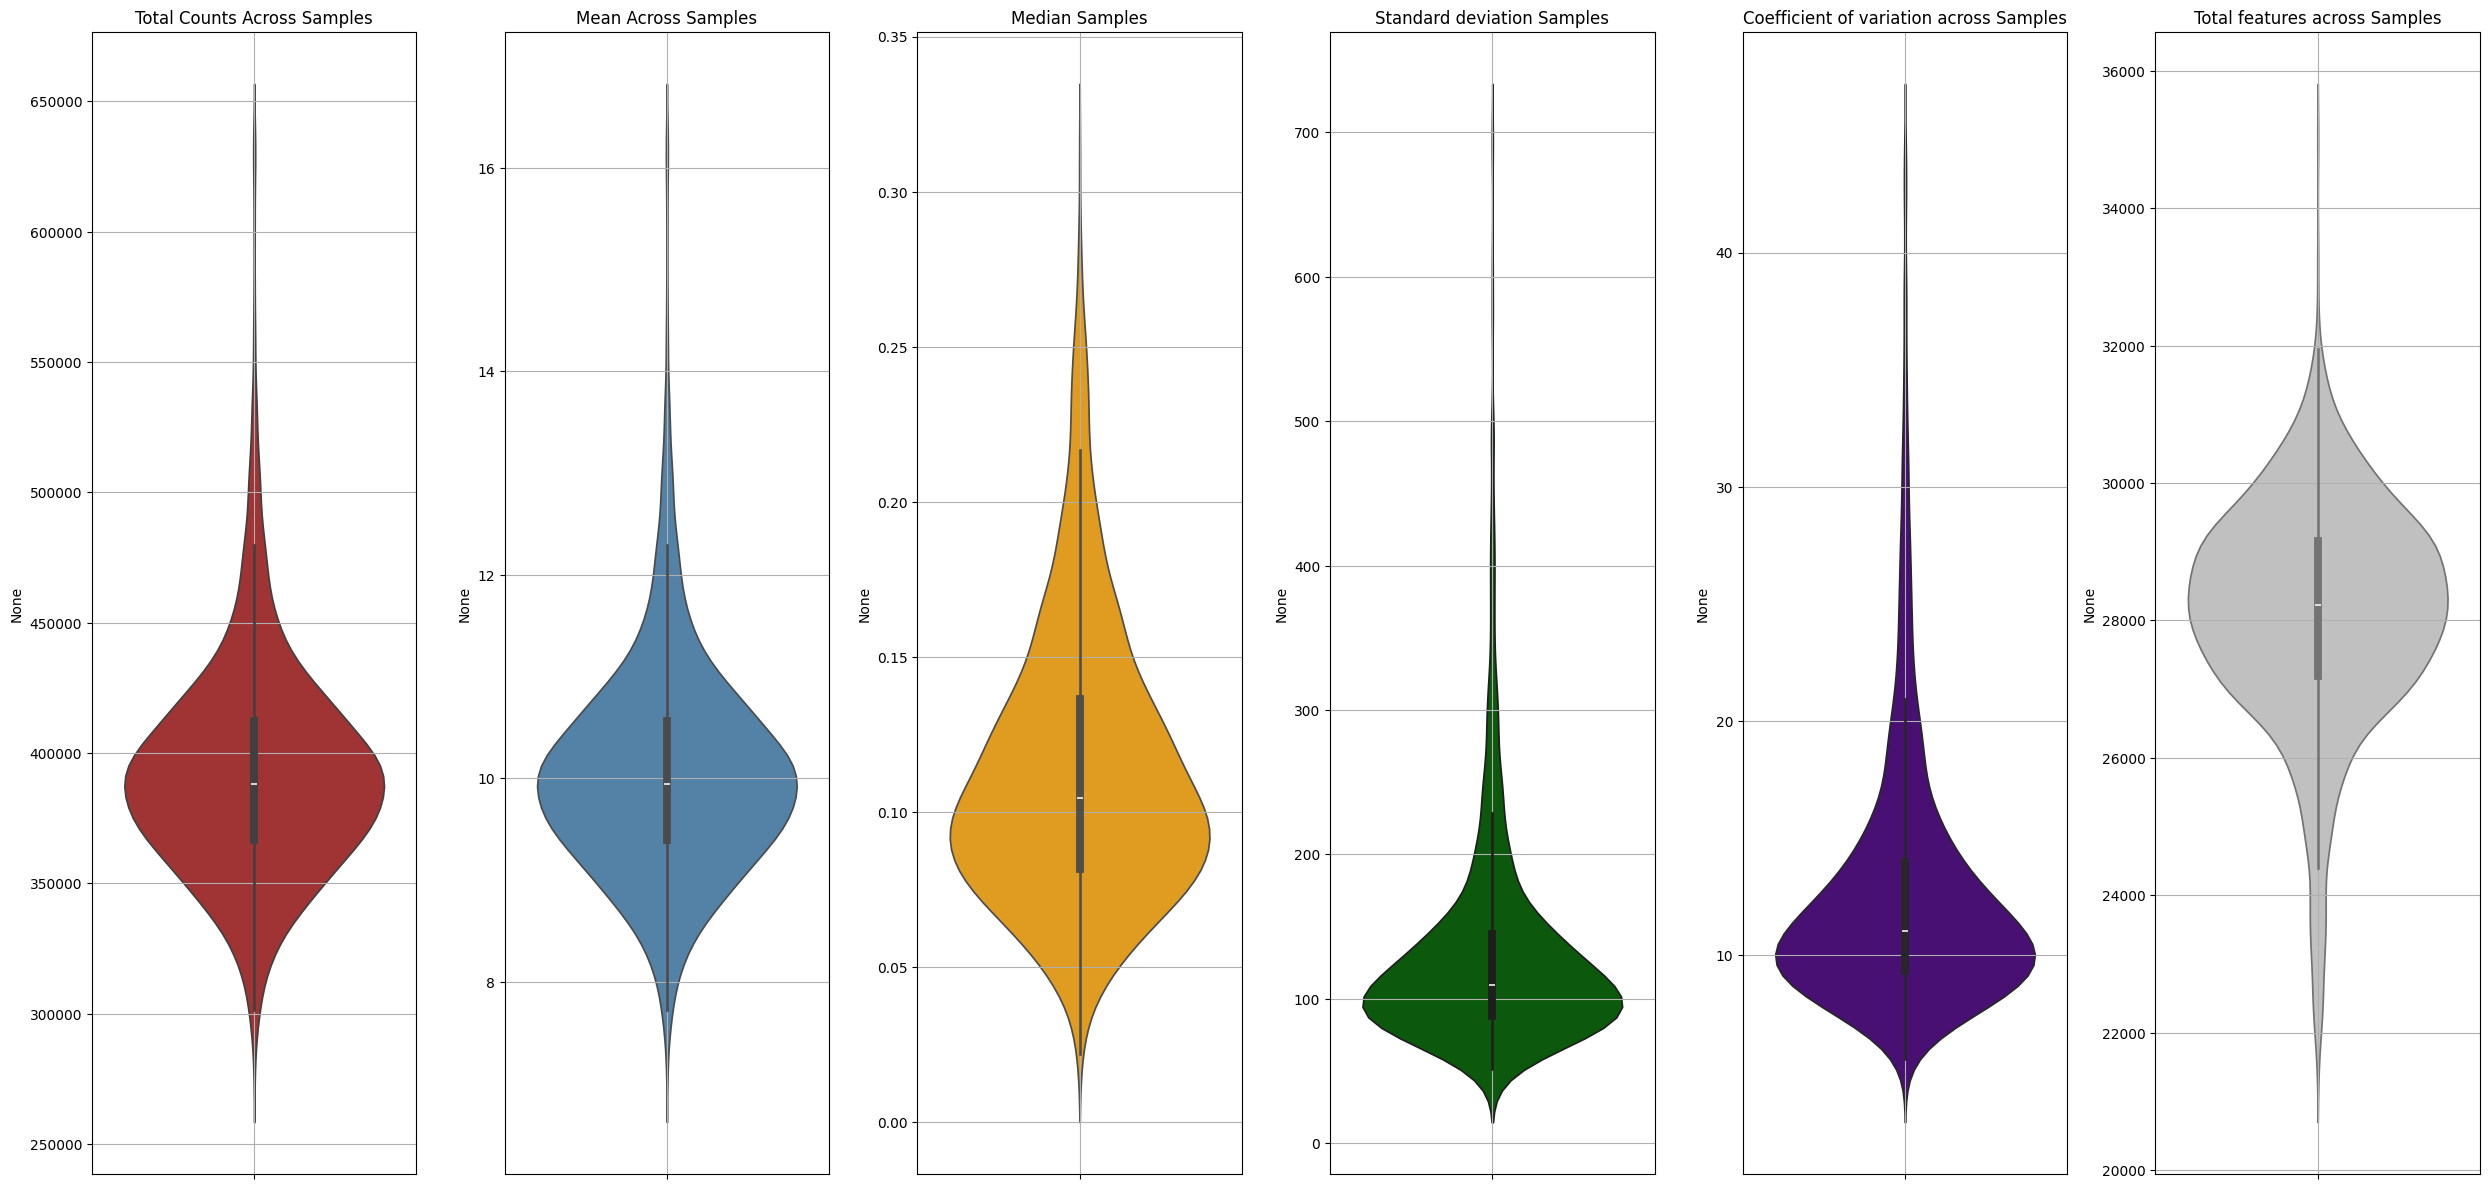

Max_total_count (636374.7491678138) - Min_total_count (278804.6958764906) = 357570.0532913232
Max_mean_count (16.303505986416976) - Min_mean_count (7.142794452808921) = 9.160711533608055
Max_median_count (0.31282) - Min_median_count (0.02193) = 0.29089
Max_std (696.9520641148556) - Min_std (51.25350565263116) = 645.6985584622245
Max CV (44.485409764223895) - Min CV (5.589446441914969) = 38.89596332230893
Max feature count  (34995) - Min feature count (21513) = 13482


In [68]:
plot_violin_metrics(mRNA_2019,0)

## Dimensionality Reduction

In [69]:
mRNA_2019_ordered = mRNA_2019[mutated_samples.tolist() + non_mutated_samples.tolist()]
mRNA_2019_ordered_log = np.log1p(mRNA_2019_ordered)
mRNA_2019_scaled = standard(mRNA_2019_ordered_log)

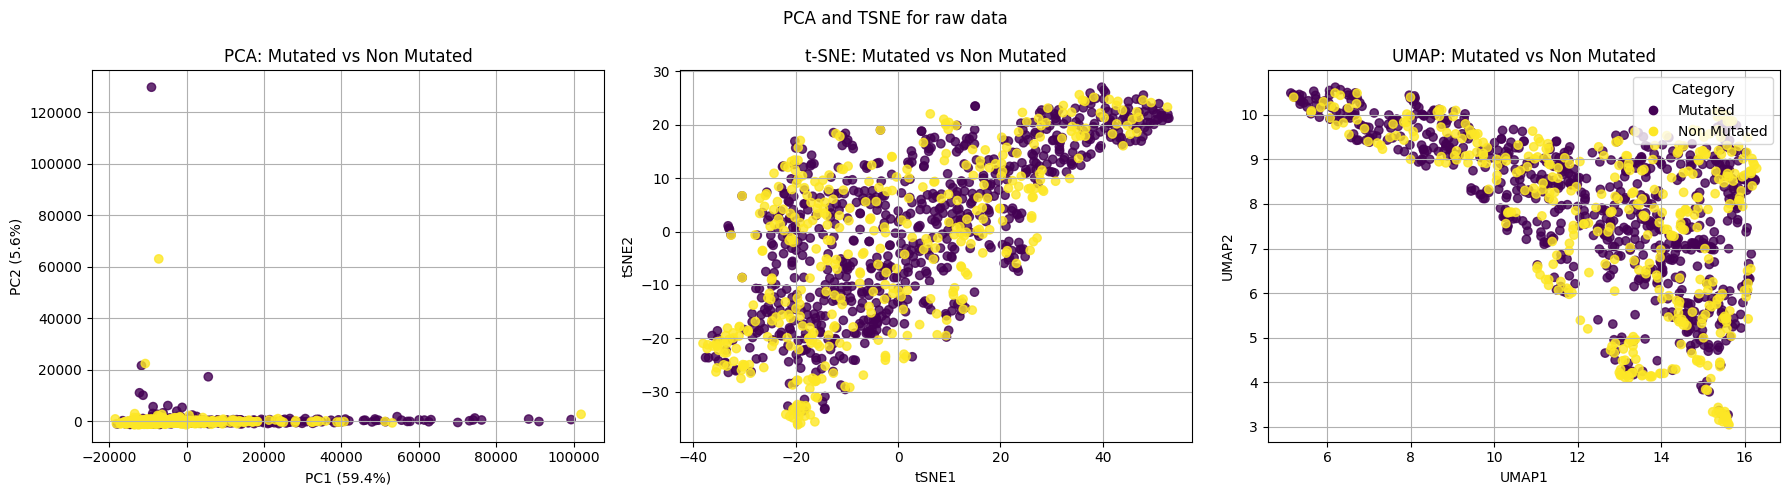

In [70]:
plot_PCA_tsne_umap(mRNA_2019_ordered,mutated_samples,non_mutated_samples,'PCA and TSNE for raw data', categories=['Mutated','Non Mutated'])

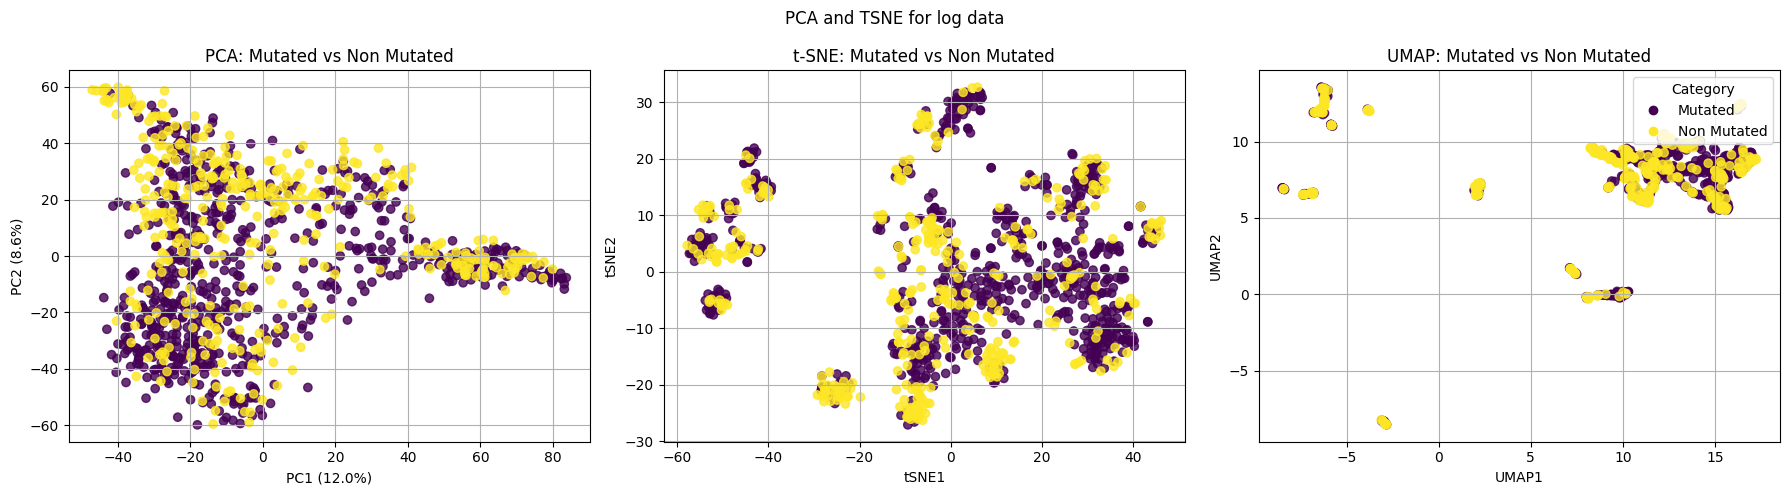

In [71]:
plot_PCA_tsne_umap(mRNA_2019_ordered_log,mutated_samples,non_mutated_samples,'PCA and TSNE for log data', categories=['Mutated','Non Mutated'])

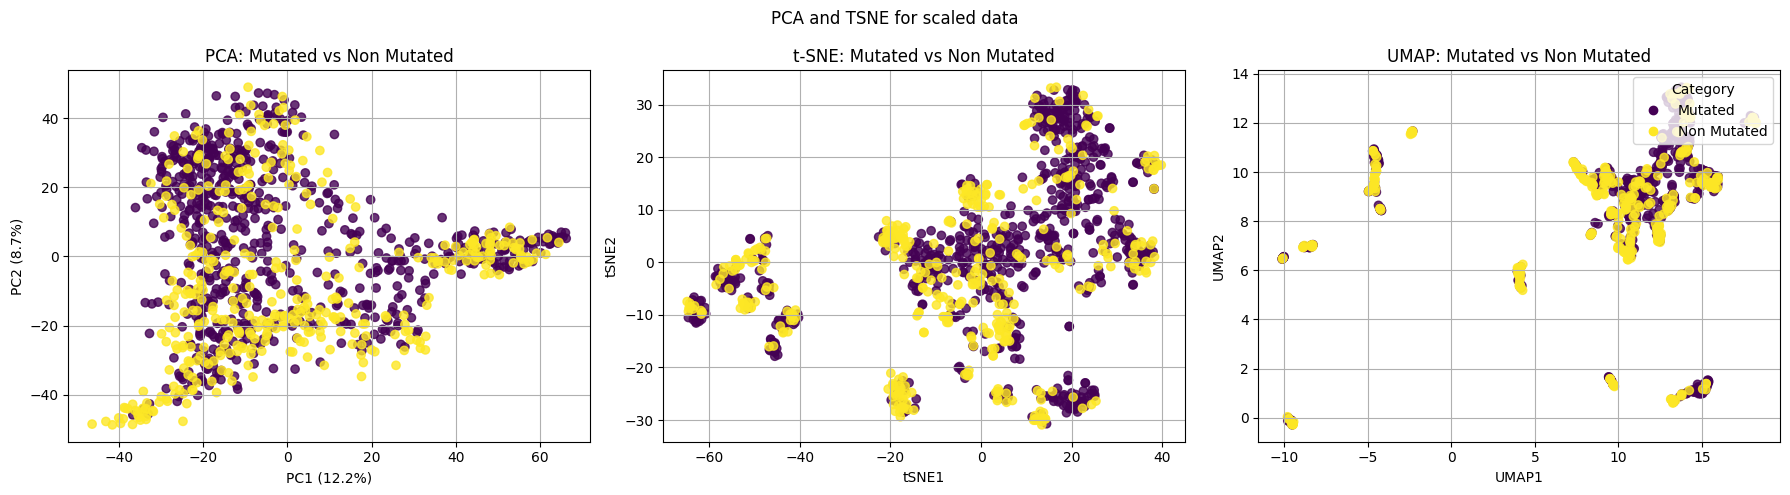

In [72]:
plot_PCA_tsne_umap(mRNA_2019_scaled,mutated_samples,non_mutated_samples,'PCA and TSNE for scaled data', categories=['Mutated','Non Mutated'])

### Visualizing Class Separability: Mutated vs Non-Mutated Samples

The plots above illustrate the separation between **mutated** and **non-mutated** samples using three different versions of the gene expression data:

1. **Raw bulk RNA-seq data**  
2. **Log-transformed data** (`log(1 + x)`)  
3. **Standardized log-transformed data**

Each representation was projected into two dimensions using **PCA**, **t-SNE**, and **UMAP**.

#### Observations:

- Across all three representations, **no clear linear separation** between mutated and non-mutated samples is visible in 2D space.
- The PCA plots suggest that variance explained by the first two components is limited, and outliers dominate raw data projections.
- t-SNE and UMAP show **better local structure**, but the clusters still contain a mix of both classes, indicating **low separability** in low-dimensional embeddings.

#### Interpretation:

Although 2D projections don’t reveal strong class separation, this does **not rule out higher-dimensional separability**. Many real-world classification problems require more than two components for effective discrimination.

To rigorously assess whether the mutation status can be predicted from gene expression, we will train **machine learning classifiers** on the high-dimensional data and evaluate their performance using appropriate metrics (e.g., accuracy, ROC AUC).


In [74]:
mRNA_2019.to_csv('../DATA/ccle_2019/CCLE_2019_filtered.csv')

## Training Data

In [75]:
X = mRNA_2019 
y = mut_all_2019.Variant_Type

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X.T, y,
    test_size=0.2,         
    stratify=y,            
    random_state=42        
)
X_train = X_train.T 
X_test = X_test.T

In [78]:
print("Train:",X_train.shape)
print("Test:",X_test.shape)
print("Train:",y_train.shape)
print("Test:",y_test.shape)

Train: (39033, 891)
Test: (39033, 223)
Train: (891,)
Test: (223,)


In [79]:
# Save all the dataframes and arrays
X_train.to_csv('../DATA/ccle_2019/X_train.csv')
X_test.to_csv('../DATA/ccle_2019/X_test.csv')
y_train.to_csv('../DATA/ccle_2019/y_train.csv')
y_test.to_csv('../DATA/ccle_2019/y_test.csv')
